# Introduction 

Since the 2014 preprint of *Volatility is Rough* by Gatheral, Jaisson, and Rosenbaum [1], the emergence of high-frequency data and the enhanced capability to compute realized variance have provided substantial evidence that volatility is "rough". Specifically, empirical studies have demonstrated that log-volatility behaves like a fractional Brownian motion with a Hurst exponent $H$ significantly smaller than $1/2$. 

In this notebook, we first perform computations to estimate the roughness of volatility (Part I). We then demonstrate how to price derivatives under rough volatility models [2] (Part II). Finally, we implement variance reduction methods to optimize the efficiency of pricing under these models [3] (Part III). The complete Python source code, including the object-oriented pricing engine and the calibration routines, is available on [GitHub](https://github.com/leandreisk/rbergomi-replication).

# I - Volatility is Rough

In **[1]**, Gatheral et al. demonstrate that log-volatility behaves as a **fractional Brownian motion (fBm)**. In this introductory section, we replicate their methodology to provide empirical evidence of this **"roughness"**. 

Formally, we define the fractional Brownian motion $W_t^H$ using the Mandelbrot-Van Ness representation: 

$$W_t^H = \frac{1}{\Gamma(H + 1/2)} \left( \int_{-\infty}^t (t - s)^{H-1/2} dW_s - \int_{-\infty}^0 (-s)^{H-1/2} dW_s \right)$$

*(Note: The normalization constant can vary depending on the chosen convention, but the core properties remain identical).*

This definition ensures that the process has **stationary increments** and the following **autocovariance structure**: 

$$\mathbb{E}[W_t^H W_s^H] = \frac{1}{2} (t^{2H} + s^{2H} - |t - s|^{2H})$$

When $H = 1/2$, $W_t^H$ recovers the properties of a **standard Brownian motion**. When $H < 1/2$, the process is "rough," meaning its trajectories are less regular (lower Hölder continuity) than those of a standard Brownian motion.

As a centered, self-similar Gaussian process with stationary increments, the fBm satisfies the following **scaling property** for any $t \in \mathbb{R}$, $\Delta \geq 0$, and $q > 0$:

$$\mathbb{E} \left[ |W_{t+\Delta}^H - W_t^H|^q \right] = K_q \Delta^{qH}$$

where $K_q$ is the $q$-th absolute moment of a standard Gaussian variable $Z \sim \mathcal{N}(0,1)$.

### Empirical Estimation of $H$

Under the assumption that log-volatility $\log(\sigma_t)$ follows a fractional Brownian motion, we can estimate $H$ by analyzing the scaling of its $q$-th moments. We define the empirical moment $m(q, \Delta)$ over a sample of $N$ observations as:

$$m(q, \Delta) = \frac{1}{N} \sum_{k=1}^{N} |\log(\sigma_{k\Delta}) - \log(\sigma_{(k-1)\Delta})|^q \approx \mathbb{E}[|\log(\sigma_{\Delta}) - \log(\sigma_0)|^q]$$

The objective is to demonstrate empirically that:

$$\log(m(q, \Delta)) \approx qH \log(\Delta) + \log(K_q)$$

By plotting $\log(m(q, \Delta))$ against $\log(\Delta)$ for a fixed $q$, we expect to observe a straight line. The Hurst exponent $H$ can then be recovered by **measuring the slope** of this line, which should be equal to $qH$.

We will use the **Oxford-Man Institute’s Realized Library**, which provides a proxy for the daily realized variance of several different indices.

### Acquiring Data and Plotting Realized Volatility of the S&P500

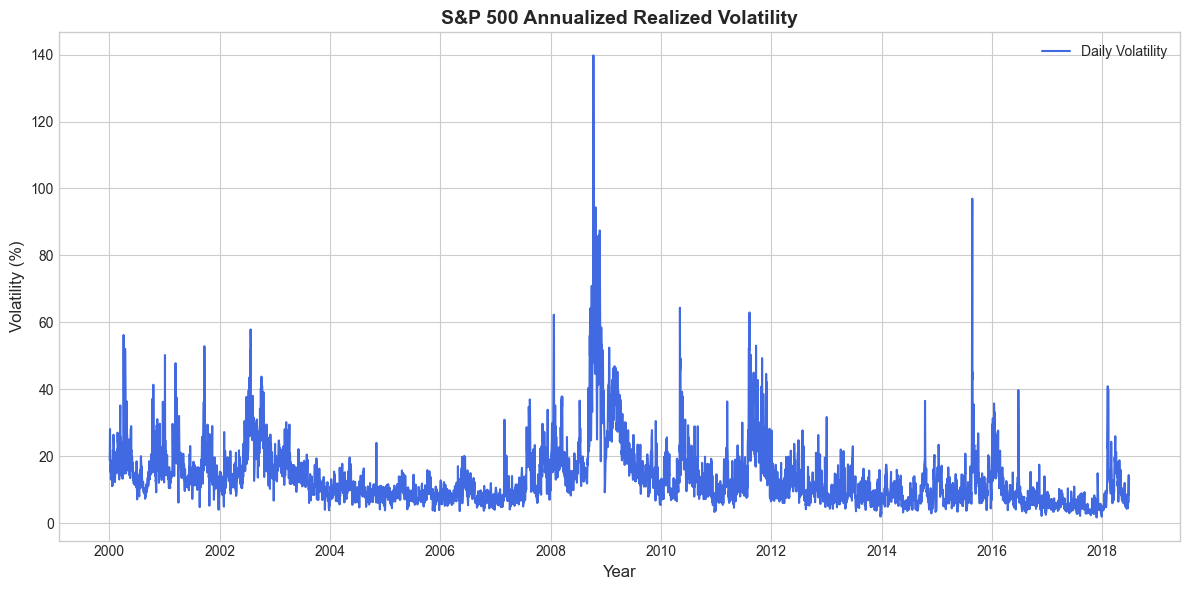

In [34]:
import sys
import os
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm
import time
from skopt import gp_minimize
from skopt.space import Real
from scipy.optimize import minimize

sys.path.append(os.path.abspath('..'))

df = pd.read_csv('../data/processed/oxfordmanrealizedvolatilityindices.csv')
df['date'] = pd.to_datetime(df['date'], utc=True)
df['date'] = df['date'].dt.tz_localize(None)
df.set_index('date', inplace=True)
df.sort_index(inplace=True)

SPX = df[df["Symbol"] == ".SPX"]

spx_vol = np.sqrt(SPX['rv5'] * 252) * 100

plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")

plt.plot(spx_vol.index, spx_vol, color='royalblue', label='Daily Volatility')

plt.title("S&P 500 Annualized Realized Volatility", fontsize=14, fontweight='bold')
plt.ylabel("Volatility (%)", fontsize=12)
plt.xlabel("Year", fontsize=12)
plt.legend()

plt.tight_layout()
plt.show()

### Observing the Hurst Parameter of the S&P500

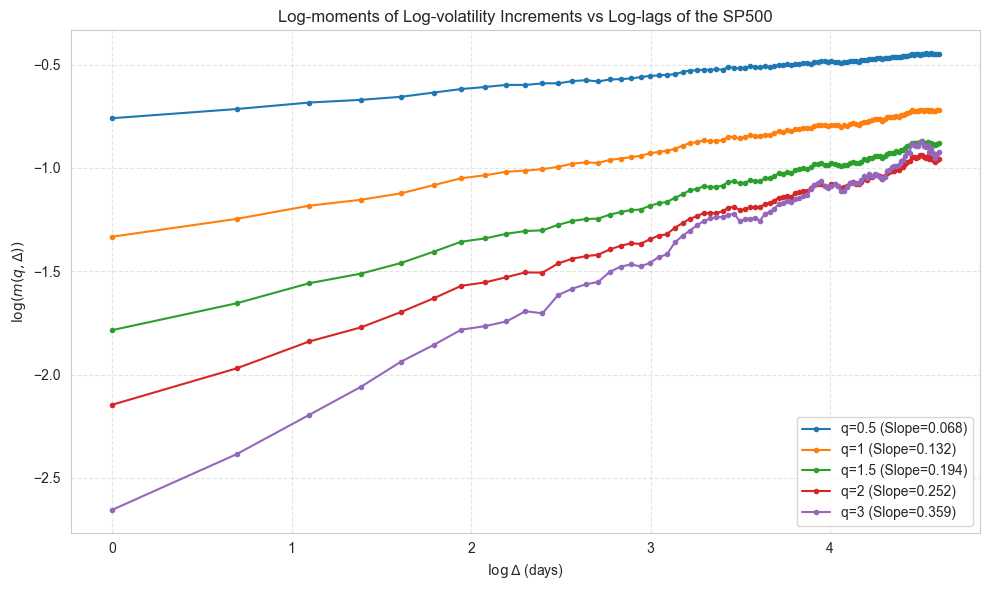

Hurst Parameter (H) Estimates by q:
q=0.5 -> H=0.135
q=1 -> H=0.132
q=1.5 -> H=0.129
q=2 -> H=0.126
q=3 -> H=0.120


In [5]:
log_vol = np.log(spx_vol)

max_lag = 100 
q_values = [0.5, 1, 1.5, 2, 3] 
lags = np.arange(1, max_lag + 1)

plt.figure(figsize=(10, 6))

hurst_estimates = {}

for q in q_values:
    moments = []
    
    for lag in lags:
        increments = log_vol.diff(lag).dropna()
        moment_q = np.mean(np.abs(increments) ** q)
        moments.append(moment_q)
    
    log_lags = np.log(lags)
    log_moments = np.log(moments)
    
    X = sm.add_constant(log_lags)
    model = sm.OLS(log_moments, X).fit()
    slope = model.params[1]
    
    hurst_estimates[q] = slope / q
    
    plt.plot(log_lags, log_moments, marker='o', markersize=3, label=f'q={q} (Slope={slope:.3f})')

plt.title("Log-moments of Log-volatility Increments vs Log-lags of the SP500")
plt.xlabel(r"$\log \Delta$ (days)")
plt.ylabel(r"$\log(m(q, \Delta))$")
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.show()

print("Hurst Parameter (H) Estimates by q:")
for q, h in hurst_estimates.items():
    print(f"q={q} -> H={h:.3f}")

#### Key Observations:

* **Scaling & Linearity**: The remarkably linear relationship across all orders $q$ and various time lags confirms the scaling property $\mathbb{E}[|\log(\sigma_{t+\Delta}) - \log(\sigma_t)|^q] \propto \Delta^{qH}$.
* **Monofractality**: The Hurst parameter $H$ remains stable across different values of $q$ (ranging from $0.120$ to $0.135$). This consistency suggests that log-volatility is **monofractal**, justifying the use of a fractional Brownian motion (fBm) over more complex multifractal models.
* **Roughness**: With $H \approx 0.13$, the trajectories exhibit significantly lower regularity than a standard Brownian motion ($H=0.5$), characterized by high "anti-persistence" or "nervousness."

#### Comparison with Gatheral et al. (2018)

Our results are in striking agreement with the original findings of Gatheral, Jaisson, and Rosenbaum [1]. As shown in their original analysis (see figure below), they consistently identified $H$ in the range of $[0.10, 0.14]$ for thousands of assets.

<img src="img/scaling_moments.png" alt="Original Figure from Gatheral et al. (2014)" style="display: block; margin: 0 auto; width: 50%; height: 50%;">

Our estimate of **$H \approx 0.13$** and the parallel structure of our log-log lines perfectly replicate Figure 2.4 of the original paper. This confirms that empirical volatility is "rough" and inconsistent with standard diffusive models.

---
**Conclusion of Part I**: The empirical evidence confirms that log-volatility regularity is best captured by a process with a Hurst exponent close to $0.1$.

# II - Pricing Under Rough Volatility

Building on the empirical evidence that volatility is rough, Bayer et al. (2016) introduced the **rough Bergomi (rBergomi)** model [2]. This model extends the forward variance framework of the original **Bergomi model** [4] to a non-Markovian setting.

In this section, we replicate the specific methodology used in the original paper. Notably, Bayer et al. did not perform a formal numerical calibration; instead, they demonstrated that the model could recover the stylized facts of the volatility surface using "guessed" (heuristic) parameters. 

We will simulate the rBergomi dynamics using a **Cholesky decomposition** to reproduce the volatility smiles and term structure curves presented by the authors. By adopting this "calibration-free" approach, we aim to show that the rBergomi model's structural form is so naturally suited to market dynamics that even simple, non-optimized parameters can achieve a remarkably decent fit to the empirical implied volatility smile. Formal optimization and variance reduction will be addressed in Part III.

### The Classic Bergomi Model

By directly modeling the **forward variance curve**, the Bergomi framework [4] inherently captures complex variance dynamics and ensures a perfect fit to the initial term structure of VIX futures or variance swaps. This approach was originally designed to price exotic options more efficiently—such as reverse cliquets or Napoleon options—which are highly sensitive to the forward skew and volatility dynamics.

The general dynamics of the classic one-factor Bergomi model are given by:

$$
\begin{aligned}
\frac{dS_t}{S_t} &= \sqrt{V_t} dZ_t \\
V_t &= \xi_t(t) \\
d\xi_t(u) &= \lambda(t, u, \xi_t) dW_t
\end{aligned}
$$

where:
* $S_t$ is the asset price.
* $V_t$ is the spot variance, defined as the current value of the forward variance $\xi_t(t)$.
* $\xi_t(u) = \mathbb{E}[\sigma_u^2 \mid \mathcal{F}_t]$ represents the forward variance for date $u$ as seen at time $t$.
* $dW_t$ and $dZ_t$ are Brownian motions with a correlation $\rho$ (capturing the leverage effect).

In the classic Bergomi model, the kernel $\lambda(t, u, \xi_t)$ is typically chosen as a decaying exponential. This choice ensures that the forward variance process remains **Markovian**, which facilitates pricing via traditional methods. 

### The rBergomi Model and its Dynamics

For the **rBergomi** model, the dynamics are transformed under the risk-neutral measure $\mathbb{Q}$ by substituting the exponential kernel with a power-law kernel. The dynamics of the one-factor rBergomi model are given by:

$$
\begin{aligned}
\frac{dS_t}{S_t} &= \sqrt{V_t} dZ_t \\
V_t &= \xi_t(t) \\
d\xi_t(u) &= \xi_t(u) \, \eta \sqrt{2H} (u-t)^{H - \frac{1}{2}} dW_t
\end{aligned}
$$

where:
* $\eta > 0$ is the vol-of-vol parameter.
* $H \in (0, 1/2)$ is the Hurst exponent, determining the "roughness" of the paths.
* $dW_t$ and $dZ_t$ are Brownian motions with correlation $\rho = d\langle W, Z \rangle_t / dt$, capturing the leverage effect.

Unlike the classic version, the power-law kernel $(u-t)^{H-1/2}$ makes the forward variance **non-Markovian**, as the dynamics at time $t$ depend on the entire history of the Brownian motion $W$. 

This yields the following dynamics for the underlying asset and its spot variance:

$$
\begin{aligned}
S_t &= S_0 \mathcal{E} \left( \int_0^t \sqrt{V_u} dZ_u \right) \\
V_u &= \xi_0(u) \mathcal{E} \left( \eta \sqrt{2H} \int_0^u (u - s)^{H-1/2} dW_s \right) = \xi_0(u) \mathcal{E} \left( \eta \tilde{W}_u \right)\\
\end{aligned}
$$

where:
* $\mathcal{E}(\cdot)$ denotes the stochastic exponential, i.e., $\mathcal{E}(X)_t = \exp(X_t - \frac{1}{2} \langle X \rangle_t)$.
* $\tilde{W}_u = \sqrt{2H} \int_0^u (u - s)^{H-\frac{1}{2}} dW_s$ is the Gaussian Volterra process (*this is identical up to a constant factor to the definition of part I*).

### Simulation via Cholesky Decomposition

Since the Volterra process $\tilde{W}$ and the Brownian motion $Z$ are jointly Gaussian, the rBergomi model is fully characterized by its covariance structure. For any $v \geq u$, the autocovariance of $\tilde{W}$ is given by:

$$\mathbb{E}[\tilde{W}_v \tilde{W}_u] = 2H u^{2H} \int_0^1 (1 - s)^{H-1/2} \left(\frac{u}{v} - s\right)^{H-1/2}ds$$

In our implementation, we approximate this integral numerically via a Riemann integral over the interval $[0, 1]$. The cross-dependence between the two drivers is then captured by:

$$\mathbb{E}[\tilde{W}_v Z_u] = \rho \frac{\sqrt{2H}}{H+1/2} \left[ v^{H+1/2} - (v - u)^{H+1/2} \right]$$

While the Brownian motion $Z$ retains its standard covariance $\mathbb{E}[Z_v Z_u] = \min(u, v)$.

To simulate these paths on a time grid $\{t_i\}_{i=1}^m$, we construct the $(2m \times 2m)$ joint covariance matrix $\Sigma$ and compute its Cholesky factor $L$ such that $\Sigma = LL^T$. Correlated paths are then generated by multiplying $L$ by a vector of i.i.d. standard normal random variables. This exact method accurately recovers the model's dynamics, although its $O(m^3)$ complexity and the density of the covariance matrix make it computationally expensive for high-resolution grids. 

For the simulation and visualization of the model, we will use the same heuristic parameters as in the paper: $H = 0.07$, $\eta = 1.9$, and $\rho = -0.9$. The authors provide a quick methodology for identifying these parameters by measuring $H$ (as discussed in Part I) and $\eta$.

### Simulation of the dynamics

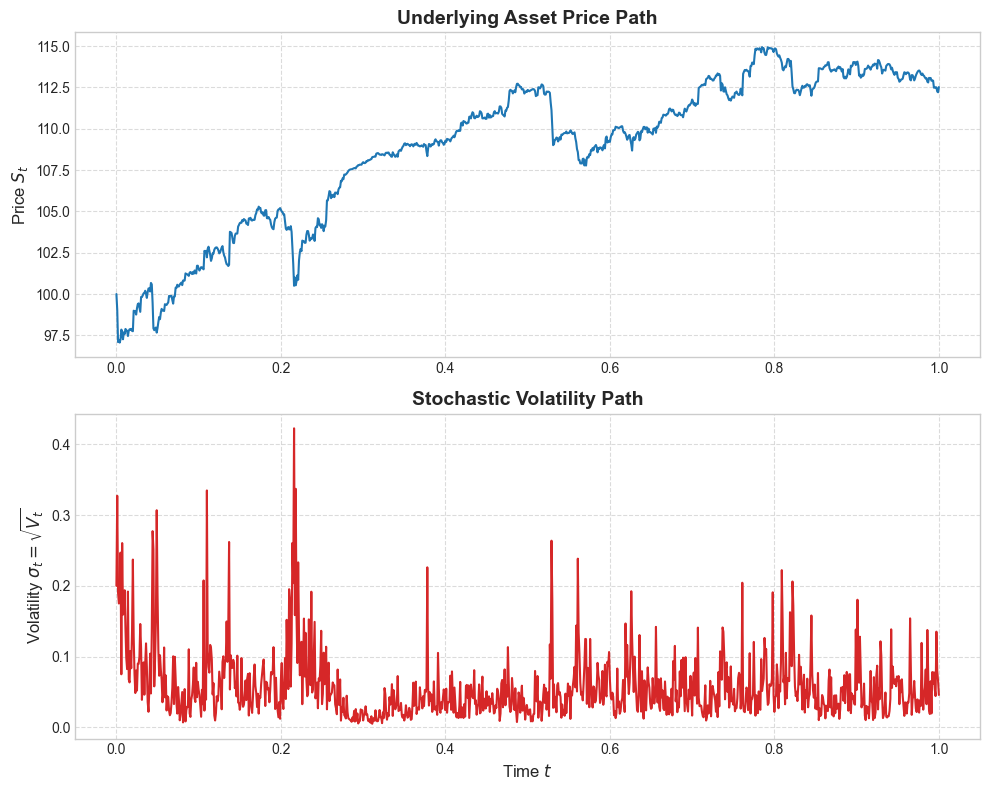

In [6]:
from src.utils.option_metrics import OptionMetricsFetcher
from src.engine.rbergomi import RBergomiEngine
from src.pricing.pricer import MonteCarloPricer, implied_volatility
from src.utils.cleaning import clean_and_filter_options, get_calibration_snapshot
from scripts.plot_term_structure import plot_volatility_term_structure

H = 0.07
eta = 1.9
rho = -0.9
model = RBergomiEngine(T=1.0, N=1000, H=H, eta=eta, rho=rho, xi_0=0.04, S_0=100, r=0.0)

V_paths, S_paths = model.simulate_cholesky(n_paths=2)

plt.figure(figsize=(10, 8))

plt.subplot(2, 1, 1)
plt.plot(model.times, S_paths[:, :1], color='#1f77b4', linewidth=1.5)
plt.title(r'Underlying Asset Price Path', fontsize=14, fontweight='bold')
plt.ylabel(r'Price $S_t$', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)

plt.subplot(2, 1, 2)
plt.plot(model.times, np.sqrt(V_paths[:, :1]), color='#d62728', linewidth=1.5)
plt.title(r'Stochastic Volatility Path', fontsize=14, fontweight='bold')
plt.xlabel(r'Time $t$', fontsize=12)
plt.ylabel(r'Volatility $\sigma_t = \sqrt{V_t}$', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

The simulated volatility path (bottom panel) closely matches the "jagged" and intermittent nature of real market data as seen in Part I. By using a Hurst parameter $H < 1/2$, the model introduces roughness. Even though the underlying asset price remains a continuous process, this roughness creates jump proxies: rapid, sharp price movements that effectively simulate market shocks without requiring a formal jump component.


### Ploting the term structure

Starting Term Structure Simulation (H=0.1, rho=-0.9)...
  -> Finished 1D (1 Day) in 0.35s
  -> Finished 1W (1 Week) in 0.34s
  -> Finished 1M (1 Month) in 0.35s
  -> Finished 3M (3 Months) in 0.36s
  -> Finished 6M (6 Months) in 0.35s
  -> Finished 1Y (1 Year) in 0.35s
Starting Term Structure Simulation (H=0.5, rho=-0.9)...
  -> Finished 1D (1 Day) in 0.35s
  -> Finished 1W (1 Week) in 0.35s
  -> Finished 1M (1 Month) in 0.35s
  -> Finished 3M (3 Months) in 0.35s
  -> Finished 6M (6 Months) in 0.35s
  -> Finished 1Y (1 Year) in 0.35s


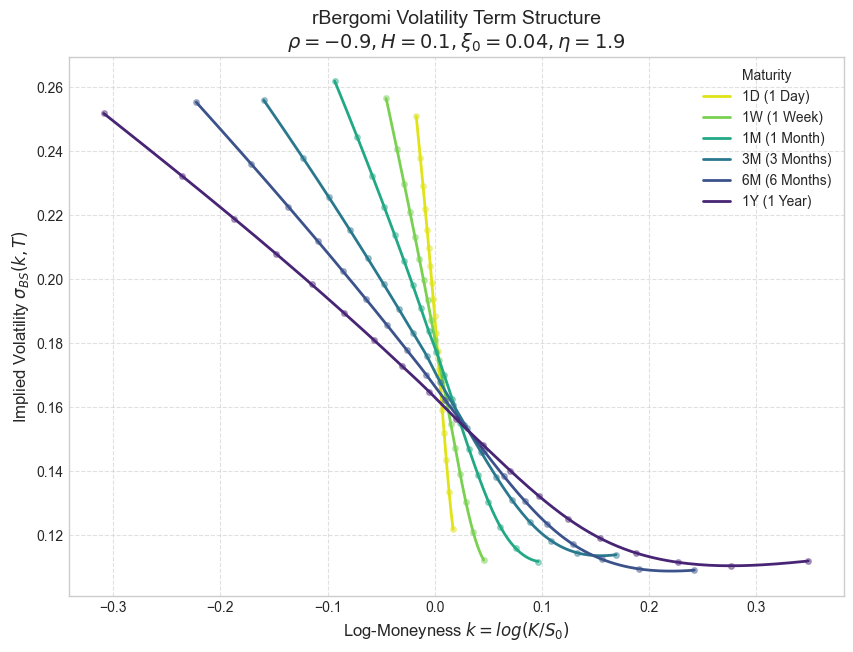

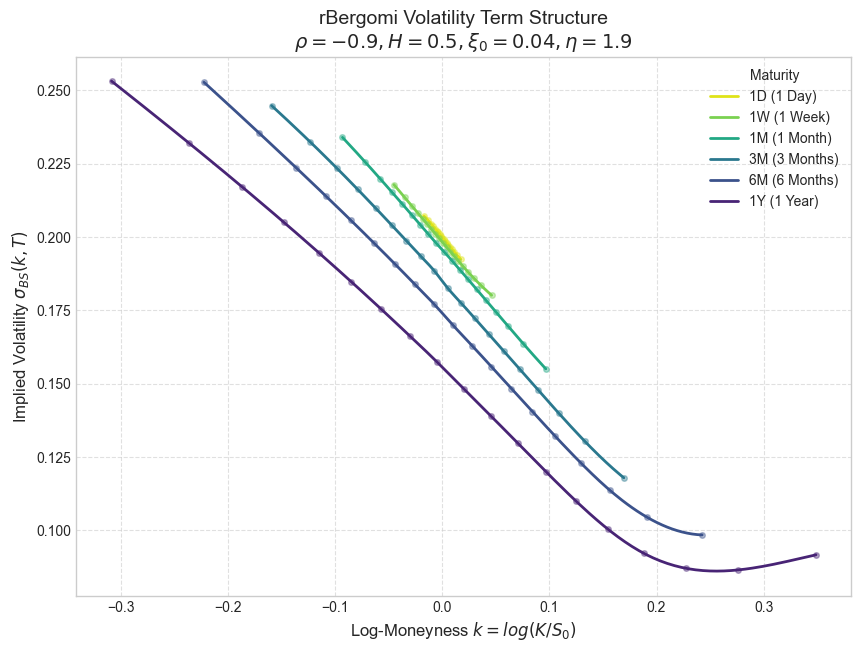

In [7]:
plot_volatility_term_structure(H=0.1, rho=-0.9, save=False)
plot_volatility_term_structure(H=0.5, rho=-0.9, save=False)

A major strength of the rBergomi model is its ability to capture the **ATM skew** (the slope of implied volatility near the money) as maturity $T \to 0$:
* **Rough Case ($H=0.1$):** The skew tends toward **infinity** as $T \to 0$. This "exploding" skew is a well-documented empirical fact in real options markets.
* **Classical Case ($H=0.5$):** Similar to a standard Heston model, the skew remains **finite** as $T \to 0$.

As shown in the figures, the $H=0.1$ term structure provides a far more realistic representation of short-term market behavior than classical stochastic volatility models.

### Model Fit: February 4, 2010

Following the approach outlined in the original article, we examine the model's fit to the implied volatility curve of European options on the S&P 500 (SPX) using the specified parameters. The market data for February 4, 2010, was retrieved from OptionMetrics via WRDS.

In [44]:
def compute_implied_forward_and_q(df_slice, S0, r, T):
    calls = df_slice[df_slice['cp_flag'].isin(['C', 'call'])].set_index('strike')['mid_price']
    puts = df_slice[df_slice['cp_flag'].isin(['P', 'put'])].set_index('strike')['mid_price']
    
    common_strikes = calls.index.intersection(puts.index)
    
    if len(common_strikes) == 0:
        raise ValueError("No common strike between calls and puts.")
    
    atm_strike = common_strikes[np.argmin(np.abs(common_strikes - S0))]
    
    c_mid = calls.loc[atm_strike]
    p_mid = puts.loc[atm_strike]
    
    F = atm_strike + (c_mid - p_mid) * np.exp(r * T)
    
    q = r - (1 / T) * np.log(F / S0)
    
    return F, q, atm_strike

def extract_xi_variance_swap(df_slice):
    S0 = df_slice["stock_price"].iloc[0]
    T = df_slice["years_to_maturity"].iloc[0]
    r = df_slice["risk_free_rate"].iloc[0]
    df = df_slice.sort_values('strike').copy()
    F = S0 * np.exp(r * T)
    
    df['price'] = (df['best_bid'] + df['best_offer']) / 2
    
    
    term_list = []
    strikes = df['strike'].values
    prices = df['mid_price'].values
    
    for i in range(1, len(strikes)-1):
        dK = (strikes[i+1] - strikes[i-1]) / 2.0
        K = strikes[i]
        Q = prices[i]
        
        contribution = (dK / (K**2)) * np.exp(r*T) * Q
        term_list.append(contribution)
        
    sigma_squared = (2 / T) * sum(term_list)
    
    return sigma_squared

om = OptionMetricsFetcher()

TICKER = 'SPX'
START = '2010-02-04'
END = '2010-02-04'

df_result = om.fetch_data(TICKER, START, END)


WRDS recommends setting up a .pgpass file.
You can create this file yourself at any time with the create_pgpass_file() function.
Loading library list...
Done


In [ ]:
df_clean = clean_and_filter_options(df_result)

target_date = '2010-02-04'
target_maturity = 0.12

calib_slice, T_exact, S0, r = get_calibration_snapshot(df_result, target_date, target_maturity)
F_implied, q_implied, atm_K = compute_implied_forward_and_q(calib_slice, S0, r, T_exact)

calib_slice, T_exact, S0, r = get_calibration_snapshot(df_clean, target_date, target_maturity)

calib_slice = calib_slice.dropna()

print(f"\n--- (S0={S0}, T={T_exact:.4f}) ---")
print(f"Risk-Free rate (r) : {r}")
print(f"Forward Implied (F) : {F_implied:.2f}")
print(f"Implied Div Yield (q) : {q_implied:.4f}")
calib_slice.sort_values("moneyness", ascending=False, inplace=True)

S_adj = S0 * np.exp(-q_implied * T_exact)

calib_slice["mid_iv"] = np.nan
calib_slice["bid_iv"] = np.nan
calib_slice["ask_iv"] = np.nan

is_call = calib_slice['cp_flag'] == 'C'
is_put = calib_slice['cp_flag'] == 'P'

if is_call.any():
    calib_slice.loc[is_call, "mid_iv"] = implied_volatility(
        calib_slice.loc[is_call, 'mid_price'].values, S_adj, 
        calib_slice.loc[is_call, "strike"].values, T_exact, r, 
        option_type='call'
    )
    calib_slice.loc[is_call, "bid_iv"] = implied_volatility(
        calib_slice.loc[is_call, 'best_bid'].values, S_adj, 
        calib_slice.loc[is_call, "strike"].values, T_exact, r, 
        option_type='call'
    )
    calib_slice.loc[is_call, "ask_iv"] = implied_volatility(
        calib_slice.loc[is_call, 'best_offer'].values, S_adj, 
        calib_slice.loc[is_call, "strike"].values, T_exact, r, 
        option_type='call'
    )

if is_put.any():
    calib_slice.loc[is_put, "mid_iv"] = implied_volatility(
        calib_slice.loc[is_put, 'mid_price'].values, S_adj, 
        calib_slice.loc[is_put, "strike"].values, T_exact, r, 
        option_type='put'
    )
    calib_slice.loc[is_put, "bid_iv"] = implied_volatility(
        calib_slice.loc[is_put, 'best_bid'].values, S_adj, 
        calib_slice.loc[is_put, "strike"].values, T_exact, r, 
        option_type='put'
    )
    calib_slice.loc[is_put, "ask_iv"] = implied_volatility(
        calib_slice.loc[is_put, 'best_offer'].values, S_adj, 
        calib_slice.loc[is_put, "strike"].values, T_exact, r, 
        option_type='put'
    )

calib_slice


--- (S0=1063.11, T=0.1205) ---
Risk-Free rate (r) : 0.002561172
Forward Implied (F) : 1060.80
Implied Div Yield (q) : 0.0201


,date,exdate,stock_price,strike,cp_flag,moneyness,mid_price,best_bid,best_offer,risk_free_rate,...,gamma,vega,theta,days_to_maturity,years_to_maturity,volume,open_interest,mid_iv,bid_iv,ask_iv
662,2010-02-04,2010-03-20,1063.11,820.0,P,1.296476,1.2,0.45,1.95,0.002494,...,0.000372,19.10534,-31.64421,44,0.120548,0.0,925.0,0.380793,0.329541,0.414007
663,2010-02-04,2010-03-20,1063.11,825.0,P,1.288618,1.375,0.7,2.05,0.002494,...,0.00041,21.09921,-35.02908,44,0.120548,303.0,29575.0,0.381609,0.343226,0.409519
664,2010-02-04,2010-03-20,1063.11,830.0,P,1.280855,1.425,0.7,2.15,0.002494,...,0.000432,21.9074,-35.85242,44,0.120548,7.0,588.0,0.376060,0.336022,0.404845
665,2010-02-04,2010-03-20,1063.11,835.0,P,1.273186,1.5,0.75,2.25,0.002494,...,0.000459,22.9605,-37.13127,44,0.120548,0.0,110.0,0.371502,0.332233,0.399999
666,2010-02-04,2010-03-20,1063.11,840.0,P,1.265607,1.65,0.9,2.4,0.002494,...,0.000496,24.696,-39.76714,44,0.120548,15.0,366.0,0.369815,0.334229,0.396614
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1582,2010-02-04,2010-03-20,1063.11,1265.0,C,0.840403,0.475,0.05,0.9,0.002494,...,0.000466,14.55629,-14.19425,44,0.120548,0.0,92.0,0.231952,0.179269,0.255046
1583,2010-02-04,2010-03-20,1063.11,1270.0,C,0.837094,0.275,0.05,0.5,0.002494,...,0.000334,9.90107,-9.157707,44,0.120548,200.0,981.0,0.219974,0.182870,0.238052
1584,2010-02-04,2010-03-20,1063.11,1275.0,C,0.833812,0.1,0.05,0.15,0.002494,...,0.000176,4.732868,-3.974485,44,0.120548,0.0,19737.0,0.199715,0.186449,0.208666
1585,2010-02-04,2010-03-20,1063.11,1280.0,C,0.830555,0.45,0.05,0.85,0.002494,...,0.000411,13.47145,-13.79525,44,0.120548,1.0,20570.0,0.243283,0.190007,0.266742


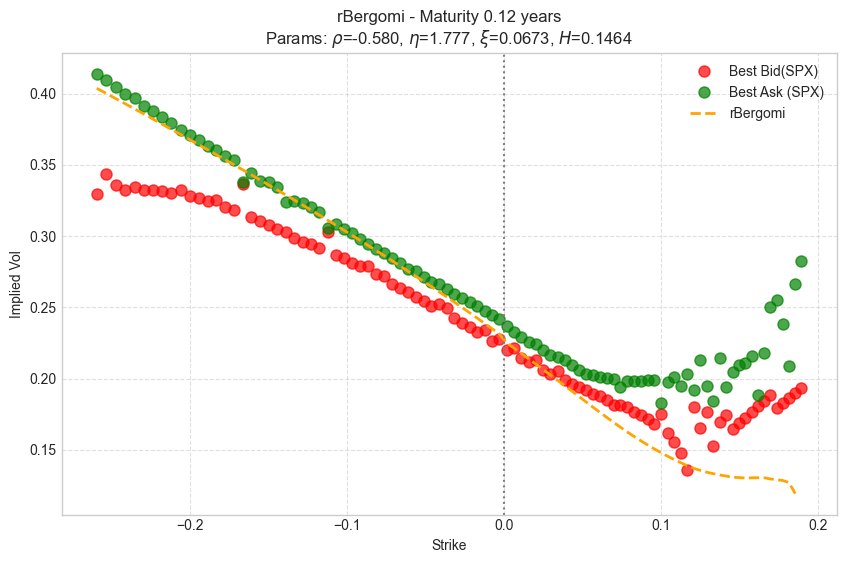

In [50]:
xi_estime = extract_xi_variance_swap(calib_slice) + 0.005
engine = RBergomiEngine(
    S_0=S0,
    T=T_exact,
    N=500,
    r=r,
    xi_0=xi_estime,
    H=H,
    rho=-0.9,
    eta=eta,
    q = q_implied
)

pricer = MonteCarloPricer(engine)

final_ivs_model = []

strikes = calib_slice['strike'].values
types = calib_slice['cp_flag'].values
bid_ivs = calib_slice['bid_iv'].values
ask_ivs = calib_slice['ask_iv'].values

model_ivs_res = np.zeros_like(bid_ivs)

mask_c = (types == 'call') | (types == 'C')
if np.any(mask_c):
    _, _, ivs_c = pricer.price_european_option(
        K=strikes[mask_c], n_paths=100000, option_type='call', return_iv=True 
    )
    model_ivs_res[mask_c] = ivs_c

mask_p = (types == 'put') | (types == 'P')
if np.any(mask_p):
    _, _, ivs_p = pricer.price_european_option(
        K=strikes[mask_p], n_paths=100000, option_type='put', return_iv=True
    )
    model_ivs_res[mask_p] = ivs_p

# --- PLOT ---
plt.figure(figsize=(10, 6))
plt.plot(np.log(strikes/S0), bid_ivs, 'o', label='Best Bid(SPX)', markersize=8, alpha=0.7, color="red")
plt.plot(np.log(strikes/S0), ask_ivs, 'o', label='Best Ask (SPX)', markersize=8, alpha=0.7, color="green")
plt.plot(np.log(strikes/S0), model_ivs_res,'--' , label=f'rBergomi', linewidth=2, color='orange')

plt.title(f"rBergomi - Maturity {T_exact:.2f} years\n"
          f"Params: $\\rho$={rho:.3f}, $\\eta$={eta:.3f}, $\\xi$={xi_estime:.4f}, $H$={H:.4f}")
plt.xlabel("Strike")
plt.ylabel("Implied Vol")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.axvline(x=r * T_exact, color='gray', linestyle=':', label='Forward Price')

plt.show()


As shown above, the rBergomi model can provide a decent fit with just heuristic parameters. Furthermore, it allows us to fit the entire implied volatility surface with only 3 parameters! If we run the model with the same parameters for the different maturity to recover the total implied volatility surface, we obtain the following fits.

<img src="img/term_structure.png" alt="Heuristic Parameters fit on the Implied Volatility Surface " style="display: block; margin: 0 auto; width: auto; height: auto;">

---
**Conclusion of Part II**: Our replication demonstrates that the rBergomi model accurately captures the empirical implied volatility surface, including the steep short-term ATM skew, using only three heuristic parameters. By leveraging a Hurst exponent $H < 1/2$, the model's non-Markovian dynamics naturally generate the rough paths required to reflect true market behavior without artificial jumps, validating its structural design and setting a solid foundation for the formal numerical optimization we will tackle in Part III.

# III - Turbocharging Monte Carlo pricing for the rough Bergomi model

While Bayer et al. [2] have shown the potential and robustness of the rBergomi model to fit market data while being parsimonious in its parameters, the rough volatility framework cannot rely on PDEs or closed/semi-closed form solutions due to its inherent non-Markovian structure. One must rely on Monte Carlo simulation to properly calibrate the model. To make calibration computationally feasible, McCrickerd and Pakkanen [3] implement a mixed estimator which combines conditional Monte Carlo with a control variate.

### Notation and Re-writing of the Model

To facilitate the variance reduction techniques, McCrickerd et al. rewrite the rBergomi model dynamics explicitly using a two-dimensional Brownian motion $(W^1, W^2)$ with independent components:

$$S_t=\mathcal{E}\left(\int_0^t\sqrt{V_u}d(\rho W_u^1+\sqrt{1-\rho^2}W_u^2)\right)$$

$$V_t=\xi_0(t)\mathcal{E}\left(\eta W_t^H\right)$$

Here $W^H$ is the Volterra process (same as defined in Part II ) : $W_t^H=\sqrt{2H}\int_0^t(t-u)^{H-1/2} dW_u^1$

This orthogonal separation of the driving Brownian motions will be crucial for introducing the control variate and the conditional Monte Carlo later on.

### The Hybrid Scheme for the Volterra Process

Simulating the fractional Volterra process $W^\alpha$ exactly using a Cholesky decomposition requires $\mathcal{O}(n^3)$ operations, which is the main computational bottleneck for calibration. To overcome this, the authors utilize the first-order variant of the Hybrid Scheme (Bennedsene et al., 2017) [5].

The scheme separates the integral into two parts: the most recent increment (which is integrated exactly to capture the singularity at $u=t$) and the historical path (which is approximated using a Riemann sum). On a time grid with $n$ steps, the approximation is:

$$W_{\frac{i}{n}}^\alpha\approx\tilde{W}_{\frac{i}{n}}^\alpha:=\sqrt{2H}\left(\int_{\frac{i-1}{n}}^{\frac{i}{n}}\left(\frac{i}{n}-u\right)^{H-1/2} dW_u^1+\sum_{k=2}^i\left(\frac{b_k}{n}\right)^{H-1/2}\left(W_{\frac{i-(k-1)}{n}}^1-W_{\frac{i-k}{n}}^1\right)\right)$$

where the optimal evaluation points $b_k$ for the Riemann sum are given by :

$$b_k:=\left(\frac{k^{\alpha+1}-(k-1)^{\alpha+1}}{\alpha+1}\right)^{\frac{1}{H-1/2}}$$

Because the summation term takes the form of a discrete convolution, the entire skeleton of the process $\hat{W}_0^\alpha,\hat{W}_{\frac{1}{n}}^\alpha,\dots,\hat{W}_{\frac{\lfloor nt \rfloor}{n}}^\alpha$ can be computed extremely efficiently in $\mathcal{O}(n\log n)$ operations using the Fast Fourier Transform (FFT) algorithm.

By running the `benchmark.py` script located in the `scripts` folder of the GitHub repository, we can measure and compare the execution times of both the exact Cholesky simulation and the Hybrid Scheme. The resulting performance benchmark is illustrated in the figure below:

<img src="img/benchmark_linear.png" alt="Benchmark comparison: Cholesky vs. Hybrid Scheme execution times" style="display: block; margin: 0 auto; width: 50%; height: auto;">

### Variance Reduction Method

The authors consider the orthogonal separation of the rBergomi price process $S_t$ into $S_t^1$ and $S_t^2$, where:
$$S_t^1 := \mathcal{E}\left(\rho \int_0^t \sqrt{V_u} dW_u^1\right), \quad S_t^2 := \mathcal{E}\left(\sqrt{1-\rho^2} \int_0^t \sqrt{V_u} dW_u^2\right)$$

By conditioning on the natural filtration $\mathcal{F}_t^1$ (the path of $W^1$), the log-price follows a normal distribution: 

$$\log S_t \mid \mathcal{F}_t^1 \vee \mathcal{F}_0^2 \sim \mathcal{N} \left( \log S_t^1 - \frac{1}{2}(1-\rho^2)\int_0^t V_u du, \ (1-\rho^2)\int_0^t V_u du \right)$$

This conditional log-normality yields the following conditional estimator given the path of $\mathcal{F}_t^1$: 

$$X = BS\left((1-\rho^2)\int_0^t V_u du; S_t^1, k\right)$$

where $BS(v, s, k)$ denotes the Black-Scholes formula where the inputs represent the total integrated variance $v$, the spot price $s$, and the log-strike $k$. The authors explicitly use the log-strike $k = \log K$ so that it remains fixed even as the spot price varies during the simulation. Finally, the function incorporates an indicator variable to systematically evaluate the option out-of-the-money (OTM), which inherently minimizes variance. To form the full Mixed Estimator, they combine this conditional expectation with a control variate $Y$:

$$\hat{P}_n(k, t) := \frac{1}{n} \sum_{i=1}^n (X_i + \hat{\alpha}_n Y_i) - \hat{\alpha}_n \mathbb{E}[Y]$$

The corresponding implied volatility estimator is then recovered by:

$$\hat{\sigma}_{BS}^n(k, t)^2 t = BS^{-1}\left(\hat{P}_n(k, t); 1, k\right)$$

The control variate $Y$ is developed as the price of a Timer option with a specific variance budget, written on the parallel component $S_t^1$: 

$$Y = BS\left(\rho^2 \left(\hat{Q}_n - \int_0^t V_u du\right); S_t^1, k\right)$$

With the empirical optimal coefficient $\hat{\alpha}_n$ and the variance budget $\hat{Q}_n$ computed post-simulation:

$$\hat{\alpha}_n := - \frac{\sum_{i=1}^n (X_i - \bar{X}_n)(Y_i - \bar{Y}_n)}{\sum_{i=1}^n (Y_i - \bar{Y}_n)^2}, \quad \hat{Q}_n := \sup \left\{ \left( \int_0^t V_u du \right)_i : i = 1, \dots, n \right\}$$

### Experimental Design and Performance Metrics

To rigorously evaluate the efficiency of our variance reduction techniques, we must analyze the empirical distribution of the pricing errors. Because the rBergomi model lacks a closed-form pricing formula, we do not have an exact theoretical implied volatility $\sigma_{BS}(k)$ to use as an absolute baseline.

To overcome this, the authors establish a "Ground Truth" (or proxy) by computing a reference implied volatility using a massive Monte Carlo simulation with 400,000 paths. We can then run our standard simulation ($n=1,000$ paths) repeatedly over $N$ independent macroscopic trials to compute the error distribution against this highly accurate proxy. This allows us to directly benchmark the classic Monte Carlo approach (the "Base" estimator) against our variance-reduced approach (the "Turbo" estimator).

For a given log-strike $k$, let $\hat{\sigma}_{BS}^n(k)_i$ be the implied volatility estimated on the $i$-th trial. The sample variance of the estimation error across $N$ trials is defined as:

$$\hat{\sigma}_{n,N,k}^2 := \frac{1}{N-1} \sum_{i=1}^N \left(\hat{\sigma}_{BS}^n(k)_i - \sigma_{BS}(k)\right)^2$$

However, measuring pure variance reduction is insufficient if the new method is computationally much slower. To fairly compare estimators, the authors introduce the **mean runtime-adjusted squared error** ($\psi^2$). Letting $\tau$ denote the average runtime required for a single estimation, and averaging the squared errors across $m$ different strikes, the metric is defined as:

$$\psi^2 := \frac{\tau}{m} \sum_{j=1}^m \hat{\sigma}_{n,N,k_j}^2$$

In [11]:
T_exact = 0.25
xi = 0.235**2
eta = 1.9
H = 0.07
S0 = 1.0
r = 0.0
q = 0.0

use_turbo=False

proxies_article = {
    -0.9: {
        '10 Delta Put': (-0.1787, 0.2961, 'put'),
        'ATM': (0.0000, 0.2061, 'call'),
        '10 Delta Call': (0.1041, 0.1576, 'call')
    },
}

def compute_local_proxies(N_grid=312, n_paths_proxy=200000):
    local_proxies = {
        -0.9: {'10 Delta Put': (-0.1787, 'put'), 'ATM': (0.0000, 'call'), '10 Delta Call': (0.1041, 'call')},
    }
    
    computed_proxies = {rho: {} for rho in local_proxies}
    
    for rho, targets in local_proxies.items():
        engine = RBergomiEngine(T=T_exact, N=N_grid, H=H, eta=eta, rho=rho, xi_0=xi, S_0=S0, r=r, q=q)
        pricer = MonteCarloPricer(engine)
        
        for label, (k, opt_type) in targets.items():
            K = S0 * np.exp(k)
            if use_turbo : 
                _, _, iv_true = pricer.price_european_option_turbo(K, n_paths_proxy, opt_type, return_iv=True)
            else : 
                _, _, iv_true = pricer.price_european_option(K, n_paths_proxy, opt_type, return_iv=True)
            
            if isinstance(iv_true, np.ndarray):
                iv_true = iv_true.item() 
            
            computed_proxies[rho][label] = (k, iv_true, opt_type)
            
            print(f"  [{rho}] {label}: Local True IV = {iv_true*100:.2f}% (Article was {proxies_article[rho][label][1]*100:.2f}%)")
    return computed_proxies

proxies = compute_local_proxies(N_grid=312, n_paths_proxy=400000)

  [-0.9] 10 Delta Put: Local True IV = 29.28% (Article was 29.61%)
  [-0.9] ATM: Local True IV = 20.17% (Article was 20.61%)
  [-0.9] 10 Delta Call: Local True IV = 15.29% (Article was 15.76%)


In [12]:
N_macro = 1000
n_paths = 1000

def run_experiment(use_turbo=False):
    results = {rho: {} for rho in proxies.keys()}
    
    for rho, targets in proxies.items():
        
        engine = RBergomiEngine(T=T_exact, N=312, H=H, eta=eta, rho=rho, xi_0=xi, S_0=S0, r=r, q=q)
        pricer = MonteCarloPricer(engine)
        
        for label, (k, true_iv, opt_type) in targets.items():
            print(f"Computing {label} (k={k:.4f})...")
            iv_samples = np.zeros(N_macro)
            K = S0 * np.exp(k) 
            
            start_time = time.time()
            
            for i in range(N_macro):
                if use_turbo:
                    _, _, iv = pricer.price_european_option_turbo(K, n_paths, opt_type, return_iv=True)
                else:
                    _, _, iv = pricer.price_european_option(K, n_paths, opt_type, return_iv=True)
                
                iv_samples[i] = iv
                
            end_time = time.time()
            
            tau_ms = ((end_time - start_time) / N_macro) * 1000 
            
            errors = 100 * (iv_samples - true_iv)
            
            results[rho][label] = {
                'errors': errors,
                'tau_ms': tau_ms,
                'k': k,
                'true_iv': true_iv * 100
            }
            
    return results

results_data = run_experiment(use_turbo=use_turbo)

Computing 10 Delta Put (k=-0.1787)...


C:\Users\leisk\AppData\Local\Temp\ipykernel_22872\15231856.py:25: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  iv_samples[i] = iv


Computing ATM (k=0.0000)...
Computing 10 Delta Call (k=0.1041)...


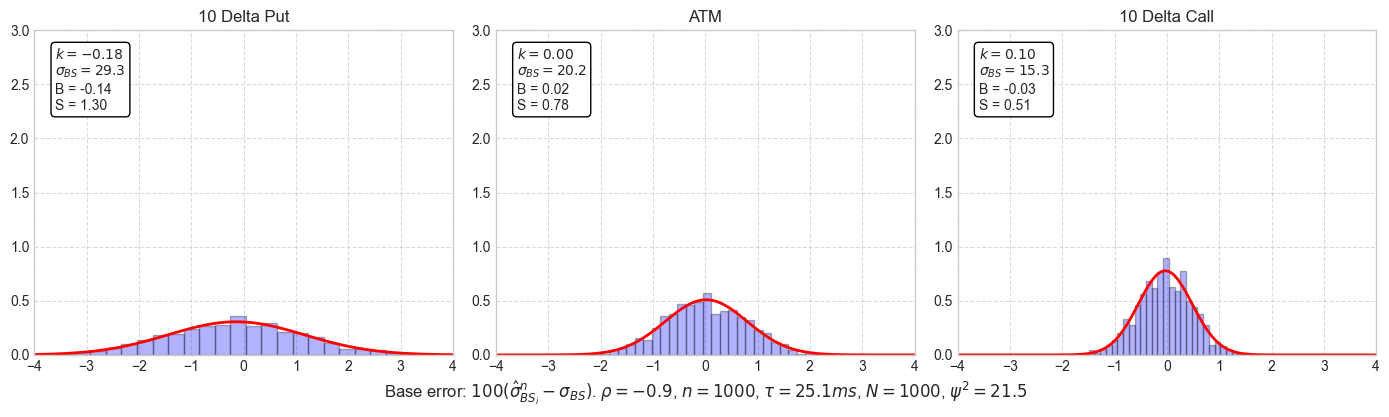

In [13]:
estimator_name = "Turbo" if use_turbo else "Base"

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

rho = -0.9

for col_idx, label in enumerate(['10 Delta Put', 'ATM', '10 Delta Call']):
    ax = axes[col_idx] 
    data = results_data[rho][label]
    
    errors = data['errors']
    B = np.mean(errors)
    S = np.std(errors)
    k = data['k']
    true_iv = data['true_iv']
    
    ax.hist(errors, bins=30, density=True, alpha=0.3, color='blue', edgecolor='black')
    
    xmin, xmax = ax.get_xlim()
    x_fit = np.linspace(-4, 4, 100)
    p = norm.pdf(x_fit, B, S)
    ax.plot(x_fit, p, 'r', linewidth=2)
    
    ax.set_xlim([-4, 4])
    if estimator_name == "Base":
        ax.set_ylim([0, 3])
    else:
        ax.set_ylim([0, 4]) 
    
    ax.grid(True, linestyle='--', alpha=0.7)
    ax.set_title(label)
    
    textstr = '\n'.join((
        f"$k = {k:.2f}$",
        f"$\\sigma_{{BS}} = {true_iv:.1f}$",
        f"B = {B:.2f}",
        f"S = {S:.2f}"
    ))
    
    props = dict(boxstyle='round', facecolor='white', alpha=1.0, edgecolor='black')
    ax.text(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=10,
            verticalalignment='top', bbox=props)

tau_mean = np.mean([results_data[rho][lbl]['tau_ms'] for lbl in ['10 Delta Put', 'ATM', '10 Delta Call']])
S_mean_sq = np.mean([np.std(results_data[rho][lbl]['errors'])**2 for lbl in ['10 Delta Put', 'ATM', '10 Delta Call']])
psi_sq = tau_mean * S_mean_sq

axes[1].set_xlabel(f"{estimator_name} error: $100(\\hat{{\\sigma}}^n_{{BS_i}} - \\sigma_{{BS}})$. $\\rho={rho}$, $n={n_paths}$, $\\tau={tau_mean:.1f}ms$, $N={N_macro}$, $\\psi^2={psi_sq:.1f}$", fontsize=12)

plt.tight_layout()
plt.subplots_adjust(bottom=0.2)
plt.show()

<img src="img/errors_turbo.png" alt="Benchmark comparison: Cholesky vs. Hybrid Scheme execution times" style="width: 77%; height: auto;">

In the distributions plotted above, each subplot is labeled with the following key statistics:
* **$k$**: The applicable log-strike.
* **$\sigma_{BS}$**: The reference "true" implied volatility targeted.
* **$B$ (Bias)**: The empirical mean of the estimation error.
* **$S$ (Standard Deviation)**: The spread of the estimation error.

The "10 Delta Put" and "10 Delta Call" levels correspond to the log-strikes of deep out-of-the-money options, defined respectively by $\mathcal{N}(-d_+) = 0.10$ and $\mathcal{N}(d_+) = 0.10$, and are specifically chosen to evaluate the accuracy of the estimator on the extreme wings of the volatility smile.

We stress again that **$\psi^2$ is the ultimate measure of performance**. It represents the true cost-efficiency of the estimator: a lower $\psi^2$ mathematically guarantees that the estimator requires less computational time to achieve a given implied volatility confidence interval during the model's calibration phase.

The Turbo estimator produces a significantly narrower distribution that is perfectly centered on zero ($B \approx 0.00$). This variance reduction is visually striking across the entire volatility smile: the standard error $S$ drops from $1.30$ to $0.53$ for the 10 Delta Put, from $0.78$ to $0.33$ for the ATM option, and from $0.51$ to $0.26$ for the 10 Delta Call. By effectively halving the standard deviation across all moneyness levels, the Turbo estimator cuts the raw variance by a factor of four. This absolute performance level ($S \approx 0.33$ ATM with $n=1000$) is remarkably consistent with the original findings reported by the authors [3]. 

While our absolute precision matches the literature, our relative runtime-adjusted efficiency gain ($\psi^2$ dropping from $19.7$ to $6.2$, a $\sim 3.2\text{x}$ improvement) is slightly less pronounced than the $\sim 5\text{x}$ improvement reported by the authors [3]. This discrepancy stems directly from our experimental design: we benchmarked against a Base estimator simulated via exact *Cholesky decomposition* rather than the approximate *Hybrid Scheme* [3]. Because the Cholesky method is mathematically exact on the given time grid, it inherently exhibits lower initial variance, making it a much harder baseline to outperform [3].

### Calibrating the Volatility Surface

With our turbocharged pricing engine fully operational, we now turn to the final objective: calibrating the rBergomi model to empirical market data. In this section, we will optimize the model parameters against the S&P 500 implied volatility surface observed on **September 16, 2022**. 

We will use an optimization routine to find the optimal set of four parameters: the Hurst exponent $H$, the vol-of-vol $\eta$, the correlation $\rho$, and the initial forward variance $\xi_0$.

For the sake of simplicity in this numerical exercise, we treat the initial forward variance $\xi_0$ as a single, flat optimizable scalar. In a rigorous production environment, the forward variance $\xi_0(t)$ should not be optimized blindly alongside the other parameters; rather, it should be extracted as a time-dependent curve directly from market instruments, such as variance swaps or VIX futures, to ensure a perfect fit to the initial term structure.

In [22]:
om = OptionMetricsFetcher()

TICKER = 'SPX'
START = '2022-09-16'
END = '2022-09-16'

df_result = om.fetch_data(TICKER, START, END)

df_clean = clean_and_filter_options(df_result)

WRDS recommends setting up a .pgpass file.
You can create this file yourself at any time with the create_pgpass_file() function.
Loading library list...
Done


In [27]:
target_date = START

all_maturities_data = []
unique_maturities = df_clean.loc[df_clean['date'] == target_date, 'years_to_maturity'].unique()

for tau in unique_maturities:
    try:
        slice_full, T_exact, S0, r = get_calibration_snapshot(df_result, target_date, tau)
        F_implied, q_implied, atm_K = compute_implied_forward_and_q(slice_full, S0, r, T_exact)
        
        calib_slice, _, _, _ = get_calibration_snapshot(df_clean, target_date, tau)
        
        if calib_slice is None or calib_slice.empty:
            continue

        S_adj = S0 * np.exp(-q_implied * T_exact)
        
        for col in ["mid_iv", "bid_iv", "ask_iv"]:
            calib_slice[col] = np.nan

        for cp, opt_type in [('C', 'call'), ('P', 'put')]:
            mask = (calib_slice['cp_flag'] == cp)
            
            if mask.any():
                calib_slice.loc[mask, "mid_iv"] = implied_volatility(
                    calib_slice.loc[mask, 'mid_price'].values, 
                    S_adj, 
                    calib_slice.loc[mask, "strike"].values, 
                    T_exact, 
                    r, 
                    option_type=opt_type
                )
                calib_slice.loc[mask, "bid_iv"] = implied_volatility(
                    calib_slice.loc[mask, 'best_bid'].values, 
                    S_adj, 
                    calib_slice.loc[mask, "strike"].values, 
                    T_exact, 
                    r, 
                    option_type=opt_type
                )
                calib_slice.loc[mask, "ask_iv"] = implied_volatility(
                    calib_slice.loc[mask, 'best_offer'].values, 
                    S_adj, 
                    calib_slice.loc[mask, "strike"].values, 
                    T_exact, 
                    r, 
                    option_type=opt_type
                )

        calib_slice["F_implied"] = float(F_implied)
        calib_slice["q_implied"] = float(q_implied)
        calib_slice["T_exact"] = float(T_exact)
        calib_slice["S0"] = float(S0)
        calib_slice["risk_free_rate"] = float(r)

        all_maturities_data.append(calib_slice)

    except Exception as e:
        pass 

if len(all_maturities_data) > 0:
    df_final_calibration = pd.concat(all_maturities_data, ignore_index=True)
    df_final_calibration.sort_values(by=["T_exact", "moneyness"], ascending=[True, False], inplace=True)
else:
    df_final_calibration = pd.DataFrame()

df_final_calibration

,date,exdate,stock_price,strike,cp_flag,moneyness,mid_price,best_bid,best_offer,risk_free_rate,...,years_to_maturity,volume,open_interest,mid_iv,bid_iv,ask_iv,F_implied,q_implied,T_exact,S0
936,2022-09-16,2022-09-26,3873.33,3000.0,P,1.29111,0.2,0.15,0.25,0.032972,...,0.027397,880.0,2641.0,0.544989,0.530784,0.556703,3878.152847,-0.012447,0.027397,3873.33
937,2022-09-16,2022-09-26,3873.33,3100.0,P,1.249461,0.3,0.25,0.35,0.032972,...,0.027397,1.0,1160.0,0.500386,0.491338,0.508375,3878.152847,-0.012447,0.027397,3873.33
938,2022-09-16,2022-09-26,3873.33,3150.0,P,1.229629,0.35,0.3,0.4,0.032972,...,0.027397,136.0,0.0,0.475325,0.467778,0.482117,3878.152847,-0.012447,0.027397,3873.33
939,2022-09-16,2022-09-26,3873.33,3200.0,P,1.210416,0.425,0.35,0.5,0.032972,...,0.027397,141.0,2091.0,0.452010,0.442629,0.460258,3878.152847,-0.012447,0.027397,3873.33
940,2022-09-16,2022-09-26,3873.33,3250.0,P,1.191794,0.5,0.45,0.55,0.032972,...,0.027397,184.0,10196.0,0.426811,0.421749,0.431523,3878.152847,-0.012447,0.027397,3873.33
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
931,2022-09-16,2027-12-17,3873.33,4600.0,C,0.842028,638.65,605.0,672.3,0.032972,...,5.254795,0.0,5.0,0.209823,0.199782,0.219888,4401.179266,0.008660,5.254795,3873.33
932,2022-09-16,2027-12-17,3873.33,4800.0,C,0.806944,564.6,532.7,596.5,0.032972,...,5.254795,0.0,4.0,0.205487,0.196053,0.214929,4401.179266,0.008660,5.254795,3873.33
933,2022-09-16,2027-12-17,3873.33,5000.0,C,0.774666,493.15,465.1,521.2,0.032972,...,5.254795,0.0,1054.0,0.200354,0.192052,0.208647,4401.179266,0.008660,5.254795,3873.33
934,2022-09-16,2027-12-17,3873.33,5200.0,C,0.744871,430.45,403.4,457.5,0.032972,...,5.254795,1.0,106.0,0.196254,0.188161,0.204318,4401.179266,0.008660,5.254795,3873.33


In [28]:
def rbergomi_calibration_objective(params, market_data, fixed_params, n_paths, seed=42):
    H, eta, rho, xi_0 = params
    S_0 = fixed_params['S_0']
    N_steps = fixed_params['N_steps']

    # np.random.seed(seed)

    total_squared_error = 0.0
    total_options = 0

    unique_maturities = market_data['T_exact'].unique()

    for T in unique_maturities:
        slice_T = market_data[market_data['T_exact'] == T]
        
        r = slice_T['risk_free_rate'].iloc[0]
        q = slice_T['q_implied'].iloc[0]

        engine = RBergomiEngine(T=T, N=N_steps, H=H, eta=eta, rho=rho, xi_0=xi_0, S_0=S_0, r=r, q=q)
        pricer = MonteCarloPricer(engine)

        dW_vol, _, z_ortho = engine._generate_hybrid_increments(n_paths)
        W_tilde = engine._fft_convolution(dW_vol, z_ortho)
        increments = (dW_vol, W_tilde)

        calls = slice_T[slice_T['cp_flag'] == 'C']
        if not calls.empty:
            K_calls = calls['strike'].values
            market_iv_calls = calls['mid_iv'].values
            
            _, _, model_iv_calls = pricer.price_european_option_turbo(
                K=K_calls, 
                n_paths=n_paths, 
                option_type='call', 
                return_iv=True, 
                increments=increments
            )
            
            error_calls = model_iv_calls - market_iv_calls
            valid_mask = ~np.isnan(error_calls)
            total_squared_error += np.sum(error_calls[valid_mask]**2)
            total_options += np.sum(valid_mask)

        puts = slice_T[slice_T['cp_flag'] == 'P']
        if not puts.empty:
            K_puts = puts['strike'].values
            market_iv_puts = puts['mid_iv'].values
            
            _, _, model_iv_puts = pricer.price_european_option_turbo(
                K=K_puts, 
                n_paths=n_paths, 
                option_type='put', 
                return_iv=True, 
                increments=increments
            )
            
            error_puts = model_iv_puts - market_iv_puts
            valid_mask = ~np.isnan(error_puts)
            total_squared_error += np.sum(error_puts[valid_mask]**2)
            total_options += np.sum(valid_mask)

    if total_options == 0:
        return 1e6 

    rmse = np.sqrt(total_squared_error / total_options)
    print("\n ---------Iteration---------")
    print(f"H : {H}")
    print(f"eta : {eta}")
    print(f"rho : {rho}")
    print(f"xi_0 : {xi_0}")
    print(f"RMSE : {rmse}")

    return rmse

def calibrate_rbergomi(market_data, S_0, N_steps=100, n_paths=10000):
    fixed_params = {
        'S_0': S_0,
        'N_steps': N_steps
    }

    initial_guess = [0.13, 1.9, -0.9, 0.06]

    bounds = (
        (0.01, 0.49),   
        (1.0, 5.0),     
        (-0.99, -0.1),  
        (0.005, 0.2)    
    )

    print("Starting optimization...")
    
    result = minimize(
        fun=rbergomi_calibration_objective,
        x0=initial_guess,
        args=(market_data, fixed_params, n_paths),
        method='Nelder-Mead',
        bounds=bounds,
        options={'maxiter': 50, 'ftol': 1e-4}
    )

    optimized_params = {
        'H': result.x[0],
        'eta': result.x[1],
        'rho': result.x[2],
        'xi_0': result.x[3],
        'success': result.success,
        'rmse': result.fun
    }

    return optimized_params

S_0 = df_final_calibration['S0'].iloc[0]

best_params = calibrate_rbergomi(df_final_calibration, S_0, N_steps=100, n_paths=1000)

print("\nOptimal Parameters Found:")
print(f"H    = {best_params['H']:.4f}")
print(f"eta  = {best_params['eta']:.4f}")
print(f"rho  = {best_params['rho']:.4f}")
print(f"xi_0 = {best_params['xi_0']:.4f}")
print(f"RMSE = {best_params['rmse']:.6f}")

Starting optimization...


C:\Users\leisk\AppData\Local\Temp\ipykernel_22872\2577393299.py:92: OptimizeWarning: Unknown solver options: ftol
  result = minimize(



 ---------Iteration---------
H : 0.13
eta : 1.9
rho : -0.9
xi_0 : 0.06
RMSE : 0.04296175458284623

 ---------Iteration---------
H : 0.1365
eta : 1.9
rho : -0.9
xi_0 : 0.06
RMSE : 0.04358602503790383

 ---------Iteration---------
H : 0.13
eta : 1.9949999999999999
rho : -0.9
xi_0 : 0.06
RMSE : 0.043688397162640925

 ---------Iteration---------
H : 0.13
eta : 1.9
rho : -0.9450000000000001
xi_0 : 0.06
RMSE : 0.04730061169990691

 ---------Iteration---------
H : 0.13
eta : 1.9
rho : -0.9
xi_0 : 0.063
RMSE : 0.03930542764948484

 ---------Iteration---------
H : 0.13324999999999998
eta : 1.9474999999999998
rho : -0.855
xi_0 : 0.0615
RMSE : 0.03769945114003267

 ---------Iteration---------
H : 0.13487499999999997
eta : 1.9712499999999995
rho : -0.81
xi_0 : 0.06225
RMSE : 0.03362803549895309

 ---------Iteration---------
H : 0.13568749999999996
eta : 1.8406249999999995
rho : -0.8549999999999999
xi_0 : 0.062625
RMSE : 0.03566332289296367

 ---------Iteration---------
H : 0.12878124999999996
eta

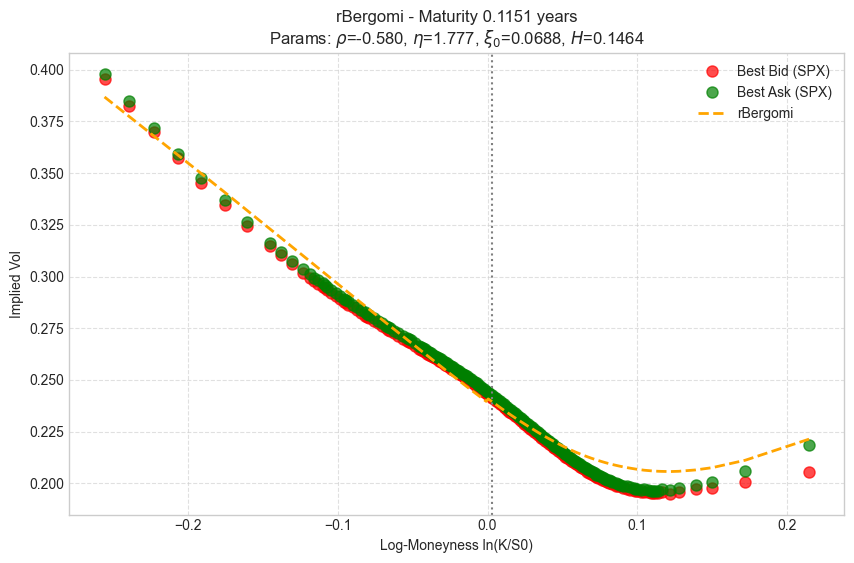

In [43]:
market_data = df_final_calibration 
target_T = 0.1
n_paths = 100000
N_steps = 312
seed = 2001

H = best_params['H']
eta = best_params['eta']
rho = best_params['rho']
xi_0 = best_params['xi_0']

unique_maturities = market_data['T_exact'].unique()
closest_T = unique_maturities[np.argmin(np.abs(unique_maturities - target_T))]

slice_T = market_data[market_data['T_exact'] == closest_T].copy()
slice_T.sort_values(by='strike', inplace=True)

S0 = slice_T['S0'].iloc[0]
r = slice_T['risk_free_rate'].iloc[0]
q = slice_T['q_implied'].iloc[0]

np.random.seed(seed)

engine = RBergomiEngine(T=closest_T, N=N_steps, H=H, eta=eta, rho=rho, xi_0=xi_0, S_0=S0, r=r, q=q)
pricer = MonteCarloPricer(engine)
slice_T['model_iv'] = np.nan

mask_c = slice_T['cp_flag'] == 'C'
if mask_c.any():
    strikes_c = slice_T.loc[mask_c, 'strike'].values
    _, _, ivs_c = pricer.price_european_option(
        K=strikes_c, 
        n_paths=n_paths, 
        option_type='call', 
        return_iv=True, 
    )
    slice_T.loc[mask_c, 'model_iv'] = ivs_c

mask_p = slice_T['cp_flag'] == 'P'
if mask_p.any():
    strikes_p = slice_T.loc[mask_p, 'strike'].values
    _, _, ivs_p = pricer.price_european_option(
        K=strikes_p, 
        n_paths=n_paths, 
        option_type='put', 
        return_iv=True, 
    )
    slice_T.loc[mask_p, 'model_iv'] = ivs_p

valid_data = slice_T.dropna(subset=['model_iv', 'bid_iv', 'ask_iv'])
strikes = valid_data['strike'].values
bid_ivs = valid_data['bid_iv'].values
ask_ivs = valid_data['ask_iv'].values
model_ivs = valid_data['model_iv'].values

log_moneyness = np.log(strikes / S0)
forward_log_moneyness = (r - q) * closest_T

plt.figure(figsize=(10, 6))

plt.plot(log_moneyness, bid_ivs, 'o', label='Best Bid (SPX)', markersize=8, alpha=0.7, color="red")
plt.plot(log_moneyness, ask_ivs, 'o', label='Best Ask (SPX)', markersize=8, alpha=0.7, color="green")
plt.plot(log_moneyness, model_ivs, '--', label='rBergomi', linewidth=2, color='orange')

plt.title(f"rBergomi - Maturity {closest_T:.4f} years\n"
          f"Params: $\\rho$={rho:.3f}, $\\eta$={eta:.3f}, $\\xi_0$={xi_0:.4f}, $H$={H:.4f}")
plt.xlabel("Log-Moneyness ln(K/S0)")
plt.ylabel("Implied Vol")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.axvline(x=forward_log_moneyness, color='gray', linestyle=':', label='Forward Price')

plt.show()

The calibration is exceptionally accurate for short to medium maturities (up to 6–8 months). The model perfectly captures the steep slopes of the implied volatility smiles. Most notably, the optimizer naturally converged to a Hurst parameter of $H \approx 0.146$. This is a powerful validation of the model's structural design, as it perfectly aligns with the empirical roughness measured directly from high-frequency market data in Part I, and confirms the findings of Gatheral et al. [1].

While the short-term fit is nearly perfect, a noticeable misalignment emerges for maturities beyond 8 months. This is an expected consequence of our simplifying assumption to model the initial forward variance $\xi_0$ as a constant scalar rather than a time-dependent curve $\xi_0(t)$. 

By forcing $\xi_0$ to be flat, the optimizer was forced to compromise. It naturally prioritized the short end of the surface—where the steep skew demands precise levels of vol-of-vol and correlation—setting the flat $\xi_0$ to match the short-term variance level. In reality, equity markets typically exhibit a term structure of forward variance (e.g., upward sloping in normal contango). A flat $\xi_0$ cannot accommodate this term structure, leading to a vertical shift in the model's implied volatility for longer-dated options.

---
**Conclusion of Part III**: This calibration demonstrates the extraordinary parsimony of the rBergomi framework. With only three structural parameters ($H$, $\eta$, $\rho$), the model achieves what classical Markovian stochastic volatility models cannot: an accurate representation of the explosive short-term ATM skew. Combined with the variance reduction techniques implemented in Part III, the rBergomi model proves to be both a theoretically sound and computationally viable solution for modern derivatives pricing.

## Conclusion

In summary, this notebook bridges the gap between empirical market observations and advanced derivatives pricing. We first established that empirical log-volatility is inherently "rough," characterized by a Hurst exponent near 0.13. Building on this statistical foundation, we implemented the rBergomi model and demonstrated its unique ability to naturally reproduce the explosive short-term ATM skew typical of equity markets. Finally, by integrating state-of-the-art variance reduction techniques, we successfully calibrated the model to the S&P 500 options surface. The optimizer's natural convergence to a roughness parameter of 0.146 elegantly brings our analysis full circle, confirming that the rough volatility framework is both remarkably parsimonious and highly practical for modern quantitative finance.

---

### References

[1] **Gatheral, J., Jaisson, T., & Rosenbaum, M. (2018).** *Volatility is rough*. Quantitative Finance, 18(6), 933-949.

[2] **Bayer, C., Friz, P., & Gatheral, J. (2016).** *Pricing under rough volatility*. Quantitative Finance, 16(6), 887-904.

[3] **McCrickerd, R., & Pakkanen, M. S. (2018).** *Turbocharging Monte Carlo pricing for the rough Bergomi model*. Quantitative Finance, 18(11), 1877-1886.

[4] **Bergomi, L. (2005).** *Smile Dynamics II*. Société Générale, Equity Derivatives Research.

[5] **Bennedsen, M., Lunde, A., & Pakkanen, M. S. (2017).** *Hybrid scheme for Brownian semistationary processes.* Finance and Stochastics, 21(4), 931–965.